In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
import os

In [34]:
def nse(y_true, y_pred):
    nse_np =1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))
    return float(nse_np)

def kge(y_true, y_pred):
    # Calculate the Pearson correlation coefficient (r)
    r, _ = pearsonr(y_true, y_pred)
    
    # Calculate the mean of the observed and predicted values
    mu_true = np.mean(y_true)
    mu_pred = np.mean(y_pred)
    
    # Calculate the standard deviation of the observed and predicted values
    sigma_true = np.std(y_true)
    sigma_pred = np.std(y_pred)
    
    # Compute the KGE
    kge_value = 1 - np.sqrt((r - 1)**2 + (sigma_pred / sigma_true - 1)**2 + (mu_pred / mu_true - 1)**2)
    
    return kge_value

In [35]:
input_file_name_list = ['1_hsg_imputMF', '2_dsk_imputMF', '3_xhl_imputMF', '4_slglk_imputMF', '5_kq_imputMF',
                        '6_wlwt_imputMF', '7_tgzlk_imputMF']
input_file_name_list = ['2_dsk_imputMF', '3_xhl_imputMF', '4_slglk_imputMF', '5_kq_imputMF', '6_wlwt_imputMF',
                        '7_tgzlk_imputMF']

In [36]:
epochs=100
batch_size= 30
os.chdir('F:\\geodata\\river_runoff_obs')

2_dsk_imputMF_BCC-CSM2-MR_ssp126_r1i1p1f1_daily_100_30_project.csv
ssp126 NSE of runoff:  0.5581055453541729
ssp126 KGE of runoff:  0.681784963251727
2_dsk_imputMF_BCC-CSM2-MR_ssp245_r1i1p1f1_daily_100_30_project.csv
ssp245 NSE of runoff:  0.5416177817945043
ssp245 KGE of runoff:  0.6814745883987048
2_dsk_imputMF_BCC-CSM2-MR_ssp370_r1i1p1f1_daily_100_30_project.csv
ssp370 NSE of runoff:  0.5278374265478099
ssp370 KGE of runoff:  0.6969468957546919
2_dsk_imputMF_BCC-CSM2-MR_ssp585_r1i1p1f1_daily_100_30_project.csv
ssp585 NSE of runoff:  0.508464131613592
ssp585 KGE of runoff:  0.6463364996273604
3_xhl_imputMF_BCC-CSM2-MR_ssp126_r1i1p1f1_daily_100_30_project.csv
ssp126 NSE of runoff:  0.5999593150533353
ssp126 KGE of runoff:  0.7946629352412028
3_xhl_imputMF_BCC-CSM2-MR_ssp245_r1i1p1f1_daily_100_30_project.csv
ssp245 NSE of runoff:  0.5102268494508369
ssp245 KGE of runoff:  0.744143117797354
3_xhl_imputMF_BCC-CSM2-MR_ssp370_r1i1p1f1_daily_100_30_project.csv
ssp370 NSE of runoff:  0.60730

D:\Users\HP\miniconda3\envs\gpd_env\Lib\site-packages\pandas\plotting\_matplotlib\core.py:580: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = self.plt.figure(figsize=self.figsize)


ssp245 NSE of runoff:  0.24316298317250096
ssp245 KGE of runoff:  0.45900408539071835
7_tgzlk_imputMF_BCC-CSM2-MR_ssp370_r1i1p1f1_daily_100_30_project.csv


FileNotFoundError: [Errno 2] No such file or directory: 'F:\\geodata\\river_runoff_obs\\7_tgzlk_imputMF_BCC-CSM2-MR_ssp370_r1i1p1f1_daily_256_30_project.csv'

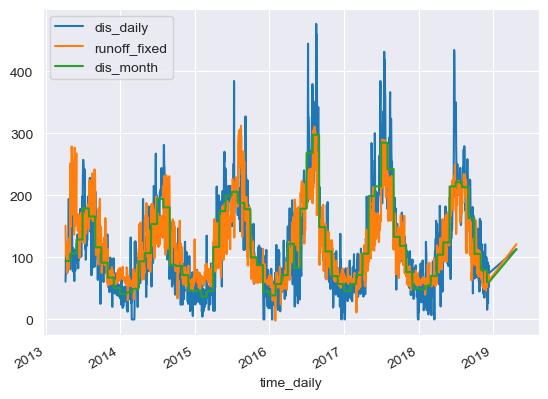

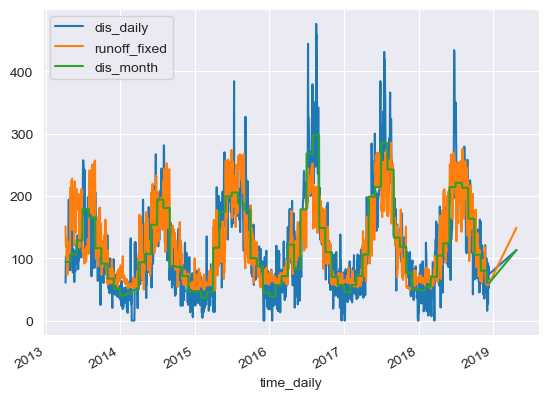

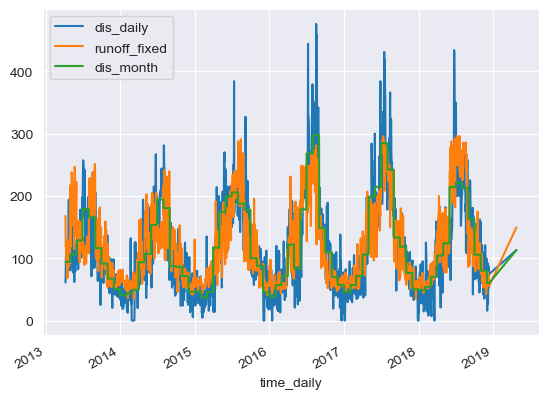

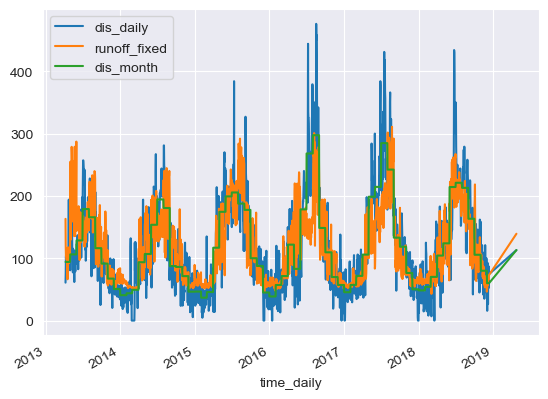

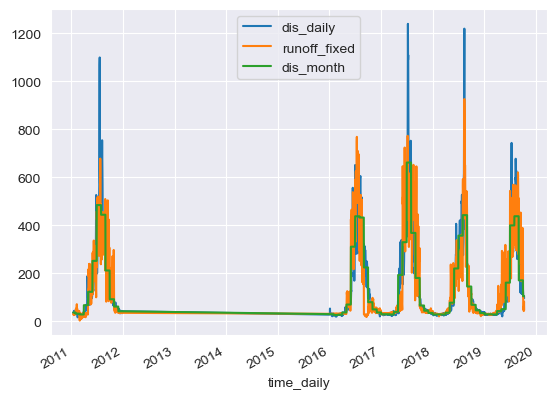

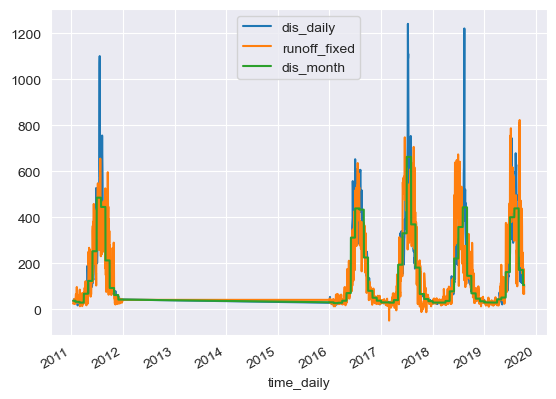

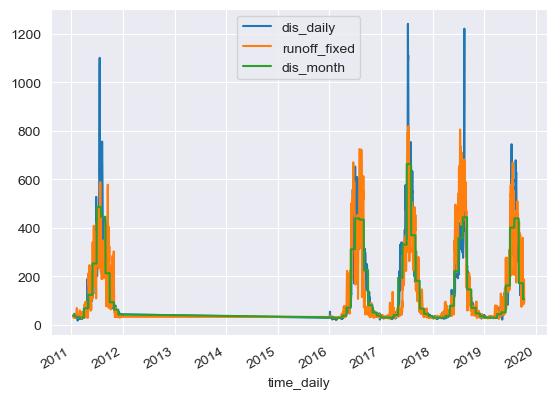

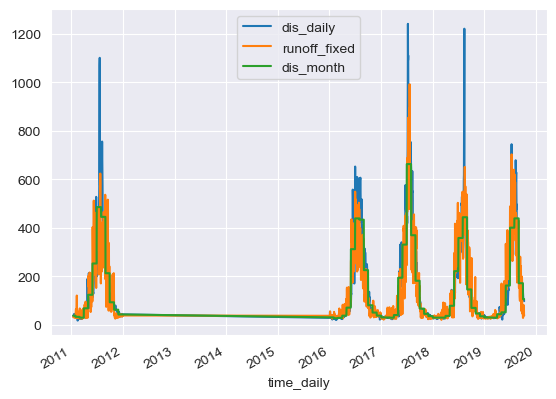

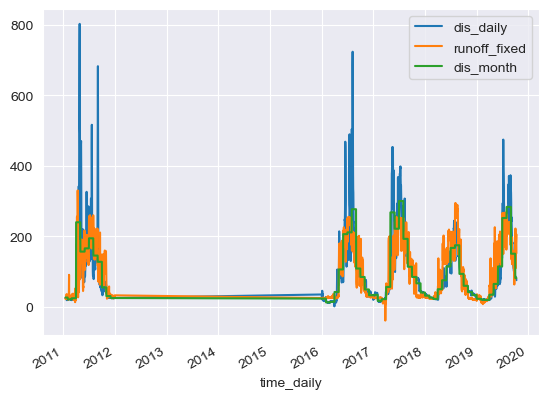

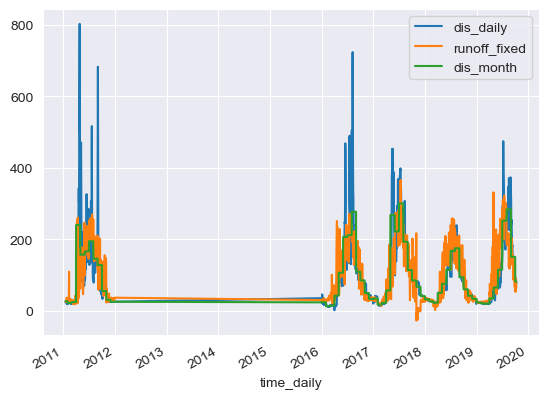

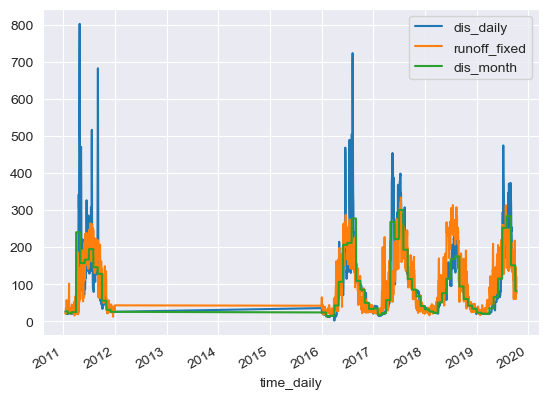

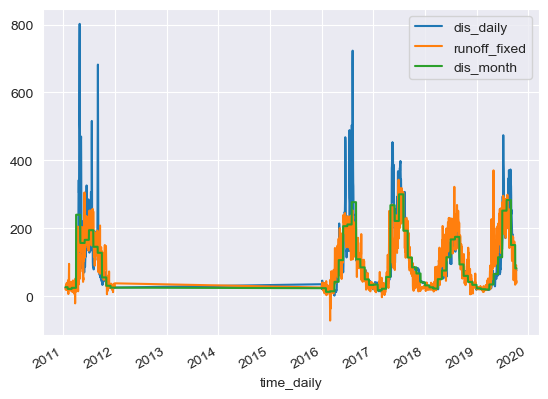

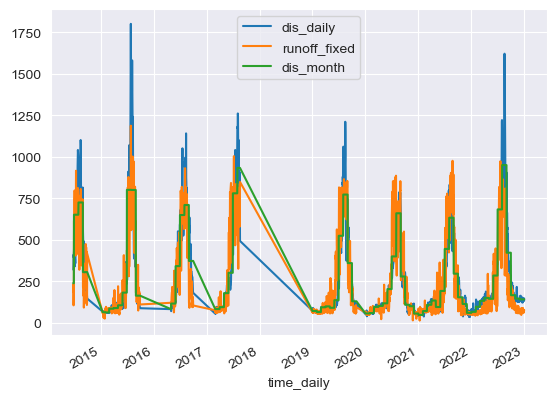

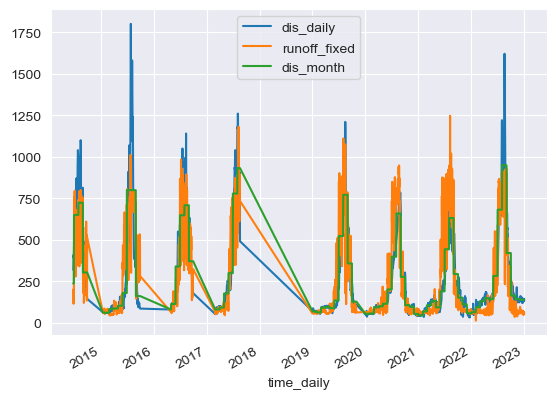

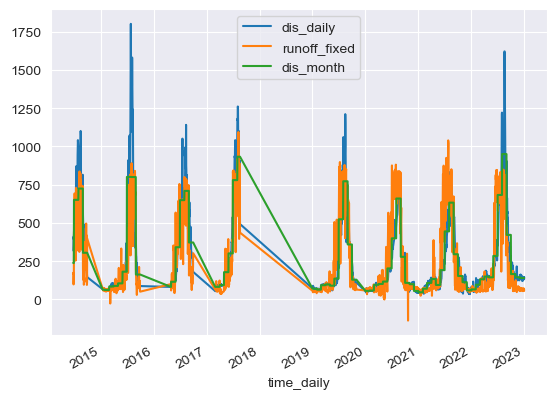

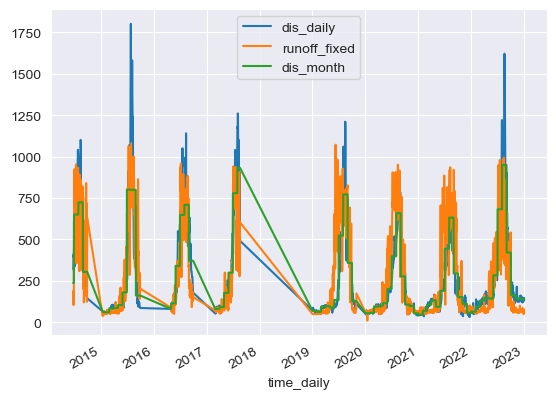

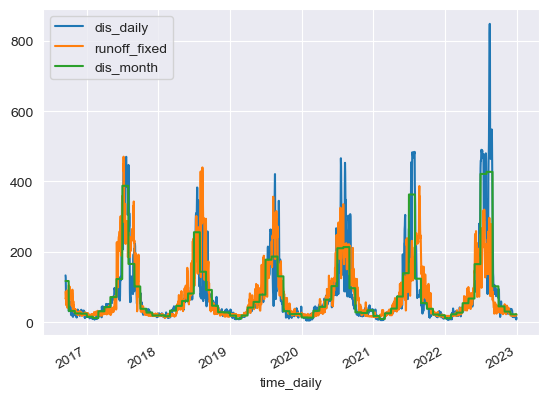

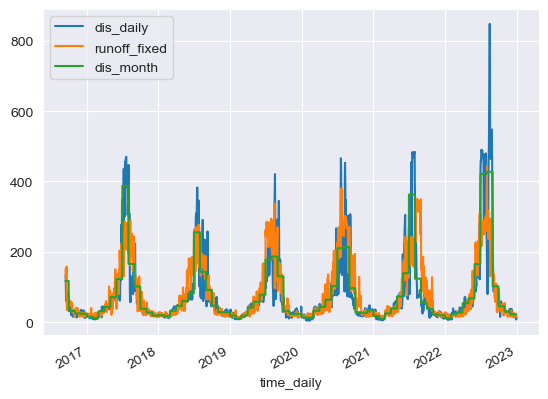

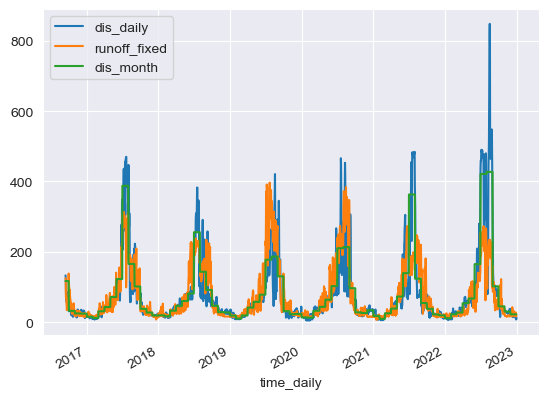

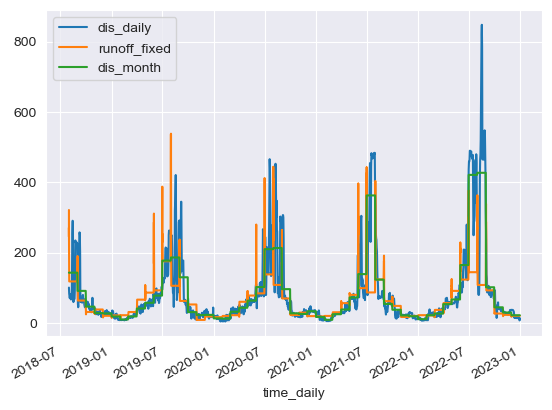

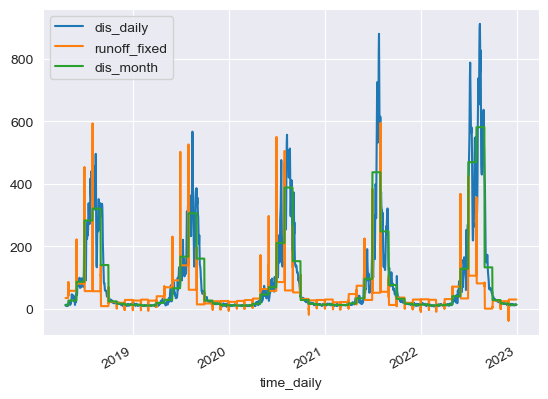

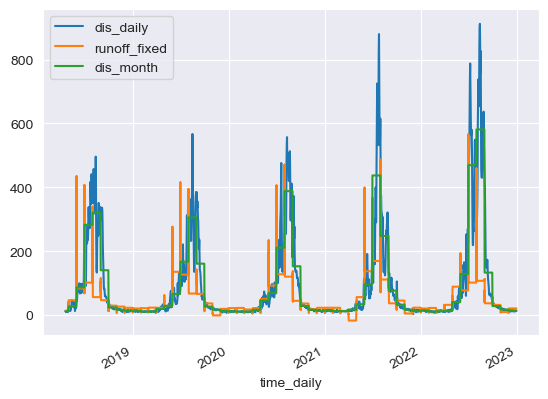

In [37]:
for input_file_name in input_file_name_list:
    abbre = input_file_name.split('_')[1]    
    for scenario in ['ssp126', 'ssp245', 'ssp370', 'ssp585']:
        name = f'{input_file_name}_BCC-CSM2-MR_{scenario}_r1i1p1f1_daily'
        file_name = f'{name}_{epochs}_{batch_size}'
        
        print(f"{file_name}_project.csv")
    
    
        month_df = pd.read_csv(f"F:\\geodata\\river_runoff_obs\\{name.replace("daily", "mon")}_256_16_project.csv")
        daily_df = pd.read_csv(f'F:\\geodata\\river_runoff_obs\\{name}_256_30_project.csv')
        # Convert the 'time' column to datetime format
        month_df['time'] = pd.to_datetime(month_df['time'])
        daily_df['time'] = pd.to_datetime(daily_df['time'])
        daily_df['date'] = daily_df['time']
        
        # Extract year and month from the 'time' column
        month_df['year_month'] = month_df['time'].dt.to_period('M')
        daily_df['year_month'] = daily_df['time'].dt.to_period('M')
        # Extract the year from 'year_month' and add it as a new column
        daily_df['year'] = daily_df.year_month.dt.year
        merged_df = pd.merge(daily_df, month_df, on='year_month', how='left', suffixes=('_daily', '_month'))
        # Group by 'year' and calculate the minimum of 'runoff' and 'ep' for each year
        annual_min = merged_df.groupby('year').agg(min_runoff=('Projected_Runoff_daily', 'min'), min_ep=('Projected_Evaporation_daily', 'min')).reset_index()
        month_mean = merged_df.groupby('year_month').agg(mean_runoff=('Projected_Runoff_daily', 'mean'), mean_ep=('Projected_Evaporation_daily', 'mean')).reset_index()
        
        merged_df= merged_df.merge(annual_min,on = 'year', how='left')
        merged_df= merged_df.merge(month_mean,on = 'year_month', how='left')
        
        # merged_df['runoff_fixed'] = (merged_df.Projected_Runoff_daily-merged_df.min_runoff)/(merged_df.mean_runoff-merged_df.min_runoff)*(merged_df.Projected_Runoff_month-merged_df.min_runoff) + merged_df.min_runoff
        # merged_df['ep_fixed'] = (merged_df.Projected_Evaporation_daily-merged_df.min_ep)/(merged_df.mean_ep-merged_df.min_ep)*(merged_df.Projected_Evaporation_month/30-merged_df.min_ep) + merged_df.min_ep
        
        merged_df['runoff_fixed'] = (merged_df.Projected_Runoff_daily-merged_df.min_runoff)/(merged_df.mean_runoff-merged_df.min_runoff)*(merged_df.Projected_Runoff_month-merged_df.min_runoff) + merged_df.min_runoff
        merged_df['ep_fixed'] = (merged_df.Projected_Evaporation_daily-merged_df.min_ep)/(merged_df.mean_ep-merged_df.min_ep)*(merged_df.Projected_Evaporation_month/30-merged_df.min_ep) + merged_df.min_ep
        historical_df = merged_df.dropna(subset=['dis_daily'])
        validation_df = historical_df.tail(int(len(historical_df)*0.3)) #here the test rate is 0.3
        validation_df.set_index('time_daily', inplace=True)
        
        print(scenario,'NSE of runoff: ',nse(validation_df['dis_daily'], validation_df['runoff_fixed']))
        print(scenario,'KGE of runoff: ',kge(validation_df['dis_daily'], validation_df['runoff_fixed']))
    
        validation_df[['dis_daily','runoff_fixed','dis_month']].plot()